In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
# DATASET AUDIT

In [6]:
df = pd.read_csv('../data/SoftwareDefectDataset.csv')
target_col = 'DEFECT_LABEL'

print("--- Dataset Audit ---")
print(f"Shape: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum().max()} max per column")
print(f"\nTarget Class Distribution:\n{df[target_col].value_counts()}")

--- Dataset Audit ---
Shape: (1000, 11)
Missing Values:
0 max per column

Target Class Distribution:
DEFECT_LABEL
0    674
1    326
Name: count, dtype: int64


In [7]:
# EDA VISUALIZATIONS

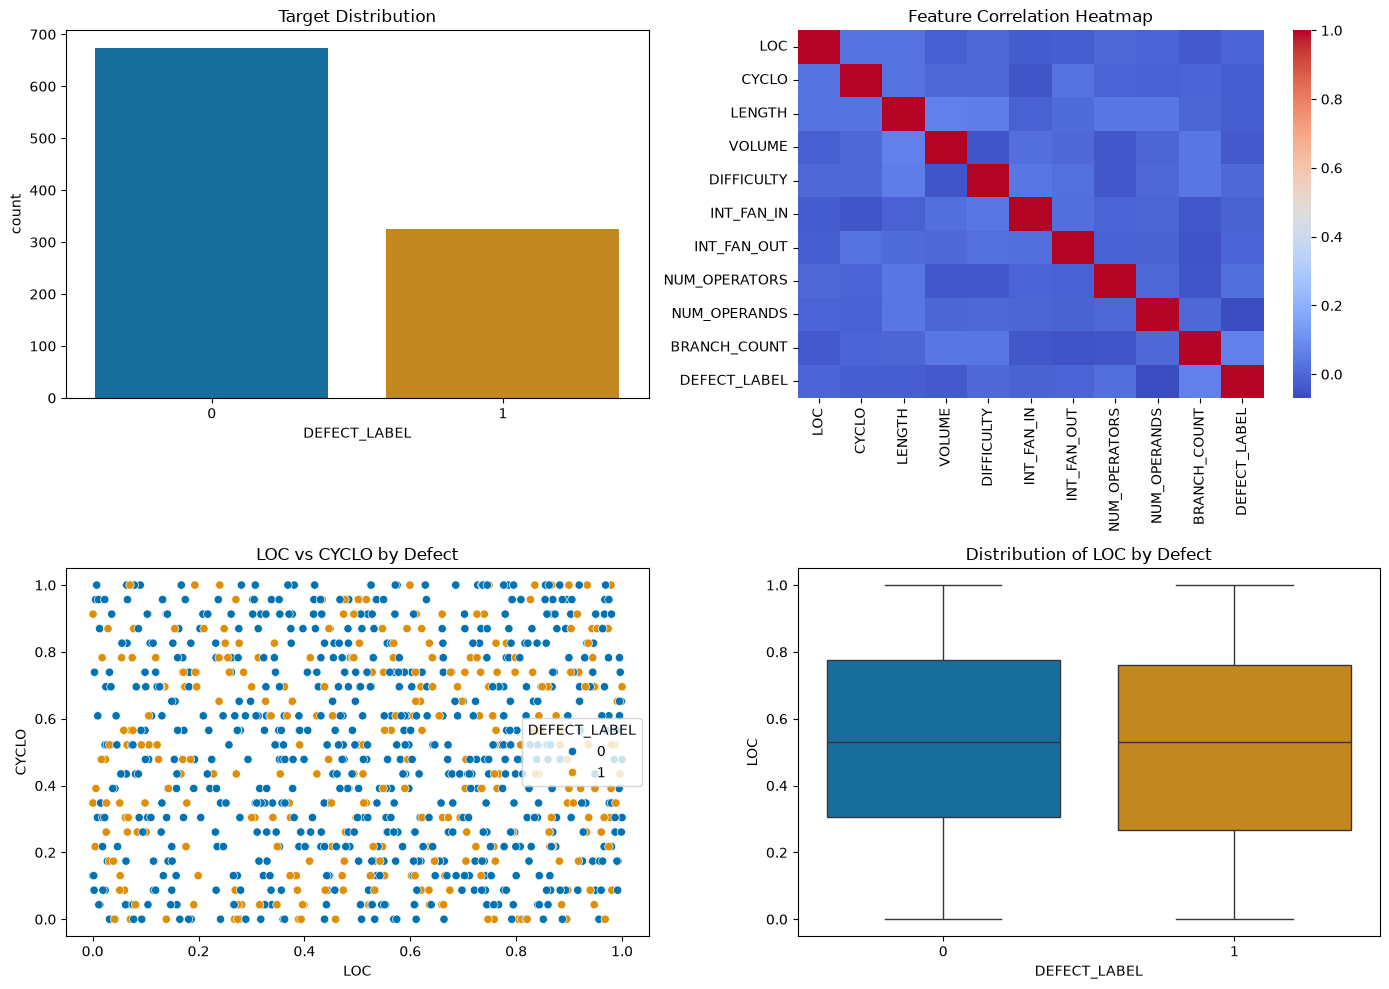

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target Distribution (Fixed FutureWarning)
sns.countplot(data=df, x=target_col, hue=target_col, palette='colorblind', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Feature Correlation Heatmap')

# Scatter Plot: LOC vs CYCLO 
# (This one was fine because hue was already assigned to target_col)
sns.scatterplot(data=df, x='LOC', y='CYCLO', hue=target_col, palette='colorblind', ax=axes[1, 0])
axes[1, 0].set_title('LOC vs CYCLO by Defect')

# Box Plot: LOC Distribution (Fixed FutureWarning)
sns.boxplot(data=df, x=target_col, y='LOC', hue=target_col, palette='colorblind', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of LOC by Defect')

plt.tight_layout()
plt.show()